<a href="https://colab.research.google.com/github/AadityaBhure/Deep-Learning-Lab---7th-Semester/blob/main/prac10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")

print(df.shape)
df.head()
print(df["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Compute class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.5008661206149896), np.int64(1): np.float64(289.14340101522845)}


In [3]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9341 - loss: 0.3500 - val_accuracy: 0.9816 - val_loss: 0.1187
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9709 - loss: 0.1863 - val_accuracy: 0.9817 - val_loss: 0.0966
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9616 - loss: 0.1766 - val_accuracy: 0.9755 - val_loss: 0.1059
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9707 - loss: 0.1370 - val_accuracy: 0.9749 - val_loss: 0.0947
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9677 - loss: 0.1285 - val_accuracy: 0.9742 - val_loss: 0.0916
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9694 - loss: 0.1187 - val_accuracy: 0.9795 - val_loss: 0.0708
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9720 - loss: 0.1221 - val_accuracy: 0.9706 - val_loss: 0.0955
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9705 - loss: 0.1105 - val_accuracy: 0.

In [5]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Predict probabilities
y_prob = model.predict(X_test)

# Convert probabilities to classes
y_pred = (y_prob > 0.5).astype(int).flatten()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Precision: 0.06343549536707056
Recall: 0.9081632653061225
F1 Score: 0.11858760826115923

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [6]:
# Show some test transactions

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Fraud Probability": y_prob.flatten()
})

results.head(10)

,Actual,Predicted,Fraud Probability
0,0,0,0.001803
1,0,0,0.002116
2,0,0,0.001743
3,0,0,0.001300
4,0,1,0.908427
5,0,0,0.002107
6,0,0,0.000003
7,0,0,0.003117
8,0,0,0.009377
9,0,0,0.002348


In [7]:
fraud_results = results[results["Actual"] == 1]

fraud_results.head(10)

,Actual,Predicted,Fraud Probability
840,1,1,0.999930
1146,1,1,1.000000
3287,1,1,1.000000
4276,1,1,0.998069
5077,1,1,1.000000
5453,1,1,0.999837
7164,1,1,0.999663
7299,1,1,1.000000
7337,1,1,0.999675
9036,1,1,1.000000


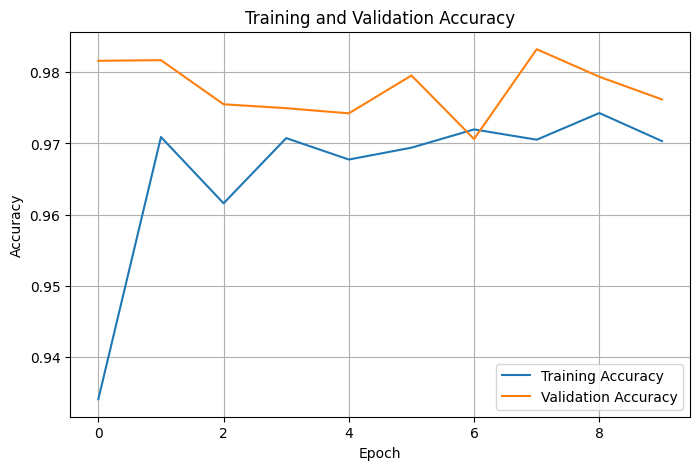

In [8]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

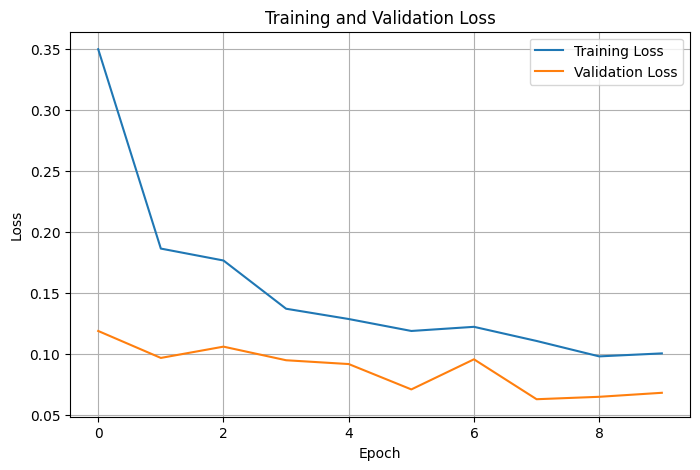

In [9]:
# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

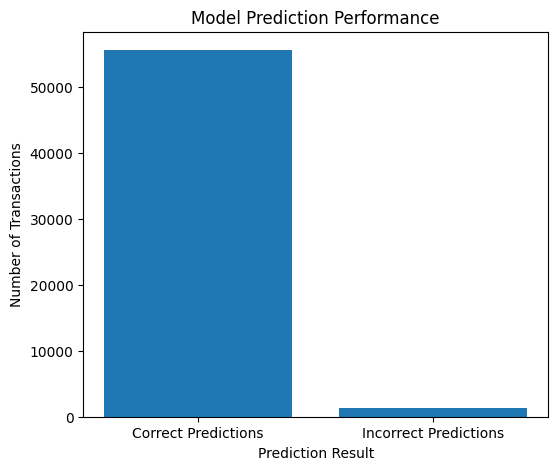

Correct Predictions: 55639
Incorrect Predictions: 1323


In [11]:
correct = np.sum(y_pred == y_test.values)
incorrect = np.sum(y_pred != y_test.values)

plt.figure(figsize=(6, 5))

plt.bar(
    ["Correct Predictions", "Incorrect Predictions"],
    [correct, incorrect]
)

plt.title("Model Prediction Performance")
plt.xlabel("Prediction Result")
plt.ylabel("Number of Transactions")

plt.show()

print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)